# Práctica 2: Regresión Lineal Múltiple

## 1. Cargar datos y librerías

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("autos2.csv")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


## 2. Definir variables predictoras y variable objetivo

In [21]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

## 3. Dividir en conjunto de entrenamiento y prueba

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4. Entrenar modelo de regresión lineal múltiple

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## 5. Evaluar el modelo

In [24]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

Error cuadrático medio (MSE): 31610677.23
Coeficiente de determinación (R²): 0.74


In [25]:
rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 5622.34


## 6. Coeficientes del modelo

In [26]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
})

print(coef_df)
print(f"Intersección (bias): {model.intercept_:.2f}")

      Variable  Coeficiente
0   horsepower    47.316135
1  engine-size    85.738718
2     city-mpg   -94.052553
3   wheel-base   263.370535
4         bore -1099.578480
Intersección (bias): -22914.90


### Interpretación

El modelo obtuvo un **RMSE de 5,622.34**, lo que indica que las predicciones del precio presentan una diferencia considerable respecto a los valores reales.

El valor de **R² = 0.74** indica que el conjunto de variables utilizadas permite explicar aproximadamente el **74% de la variación del precio** de los automóviles.

En comparación con el modelo de regresión lineal simple, la incorporación de varias características del vehículo permite representar mejor las diferencias existentes en los precios.

## 7. Comparar precios reales vs. predichos

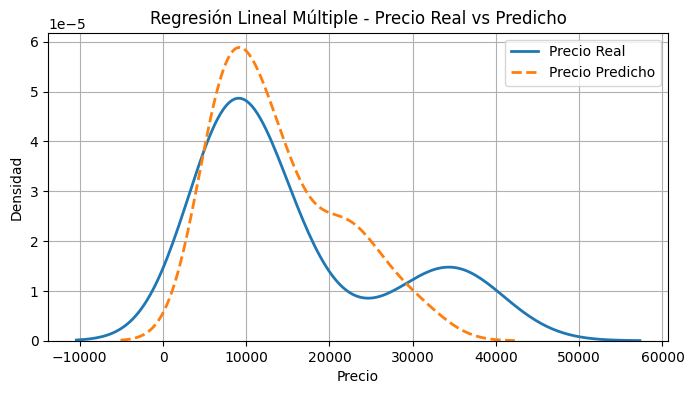

In [27]:
plt.figure(figsize=(8, 4))

sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')

plt.xlabel("Precio")
plt.ylabel("Densidad")
plt.title("Regresión Lineal Múltiple - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

### Puntos clave del gráfico

Las distribuciones de los precios reales y predichos presentan una mayor similitud que en el modelo de regresión lineal simple. El modelo logra representar mejor la tendencia general de los precios, aunque todavía existen diferencias entre ambas distribuciones.

El valor de **R² = 0.74** indica que el modelo captura una parte importante de la variabilidad del precio, aunque todavía existe variación que no es explicada por las variables utilizadas.

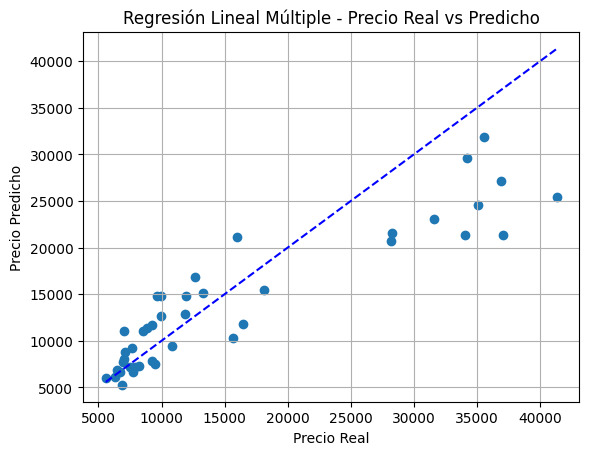

In [28]:
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'b--'
)

plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresión Lineal Múltiple - Precio Real vs Predicho")
plt.grid(True)
plt.show()

### Interpretación

Los puntos muestran una tendencia creciente entre el precio real y el precio predicho, lo que indica que el modelo logra representar la relación general entre las características de los automóviles y su precio.

Los puntos cercanos a la línea diagonal representan predicciones con menor diferencia respecto al valor real. Sin embargo, todavía existe dispersión, lo que indica que el modelo presenta errores de predicción en algunos casos.

En general, la regresión lineal múltiple presenta un mejor ajuste que la regresión lineal simple al utilizar varias características del automóvil para estimar su precio.